## Linear Regression Example

You are a real estate agent and want to predict housing prices for regions in the USA. Create a model that allows to put in a few features of a house and returns back an estimate of what the house would sell for.

The data contains the following columns:

* **Avg. Area Income:** Avg. Income of residents of the city house is located in.
* **Avg. House Age:** Avg Age of Houses in the same city.
* **Avg. Number of Rooms:** Avg number of rooms for houses in same city.
* **Avg. Number of Bedrooms:** Avg number of bedrooms for houses in the same city.
* **Area Population:** Population of city house is located in.
* **Price:** Price that the house was sold at.
* **Address:** Address for the house.

### Import the data

In [1]:
!curl https://raw.githubusercontent.com/markumreed/colab_sklearn/main/housing.csv >> housing.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  709k  100  709k    0     0   341k      0  0:00:02  0:00:02 --:--:--  341k


In [2]:
!ls

housing.csv  linear-regression-example.ipynb


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
housing = pd.read_csv('housing.csv')
housing

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386
...,...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316


In [5]:
housing.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [6]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [7]:
housing.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [15]:
housing.columns = [x.lower().replace(".", "").replace("area", "").replace("  ", " ").replace(" ", "_") for x in housing.columns] # List comprehension

In [22]:
housing = housing.rename(columns={'_population': 'area_population'}) 

In [23]:
housing

,avg_income,avg_house_age,avg_number_of_rooms,avg_number_of_bedrooms,area_population,price,address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386
...,...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316


### Exploratory Data Analysis

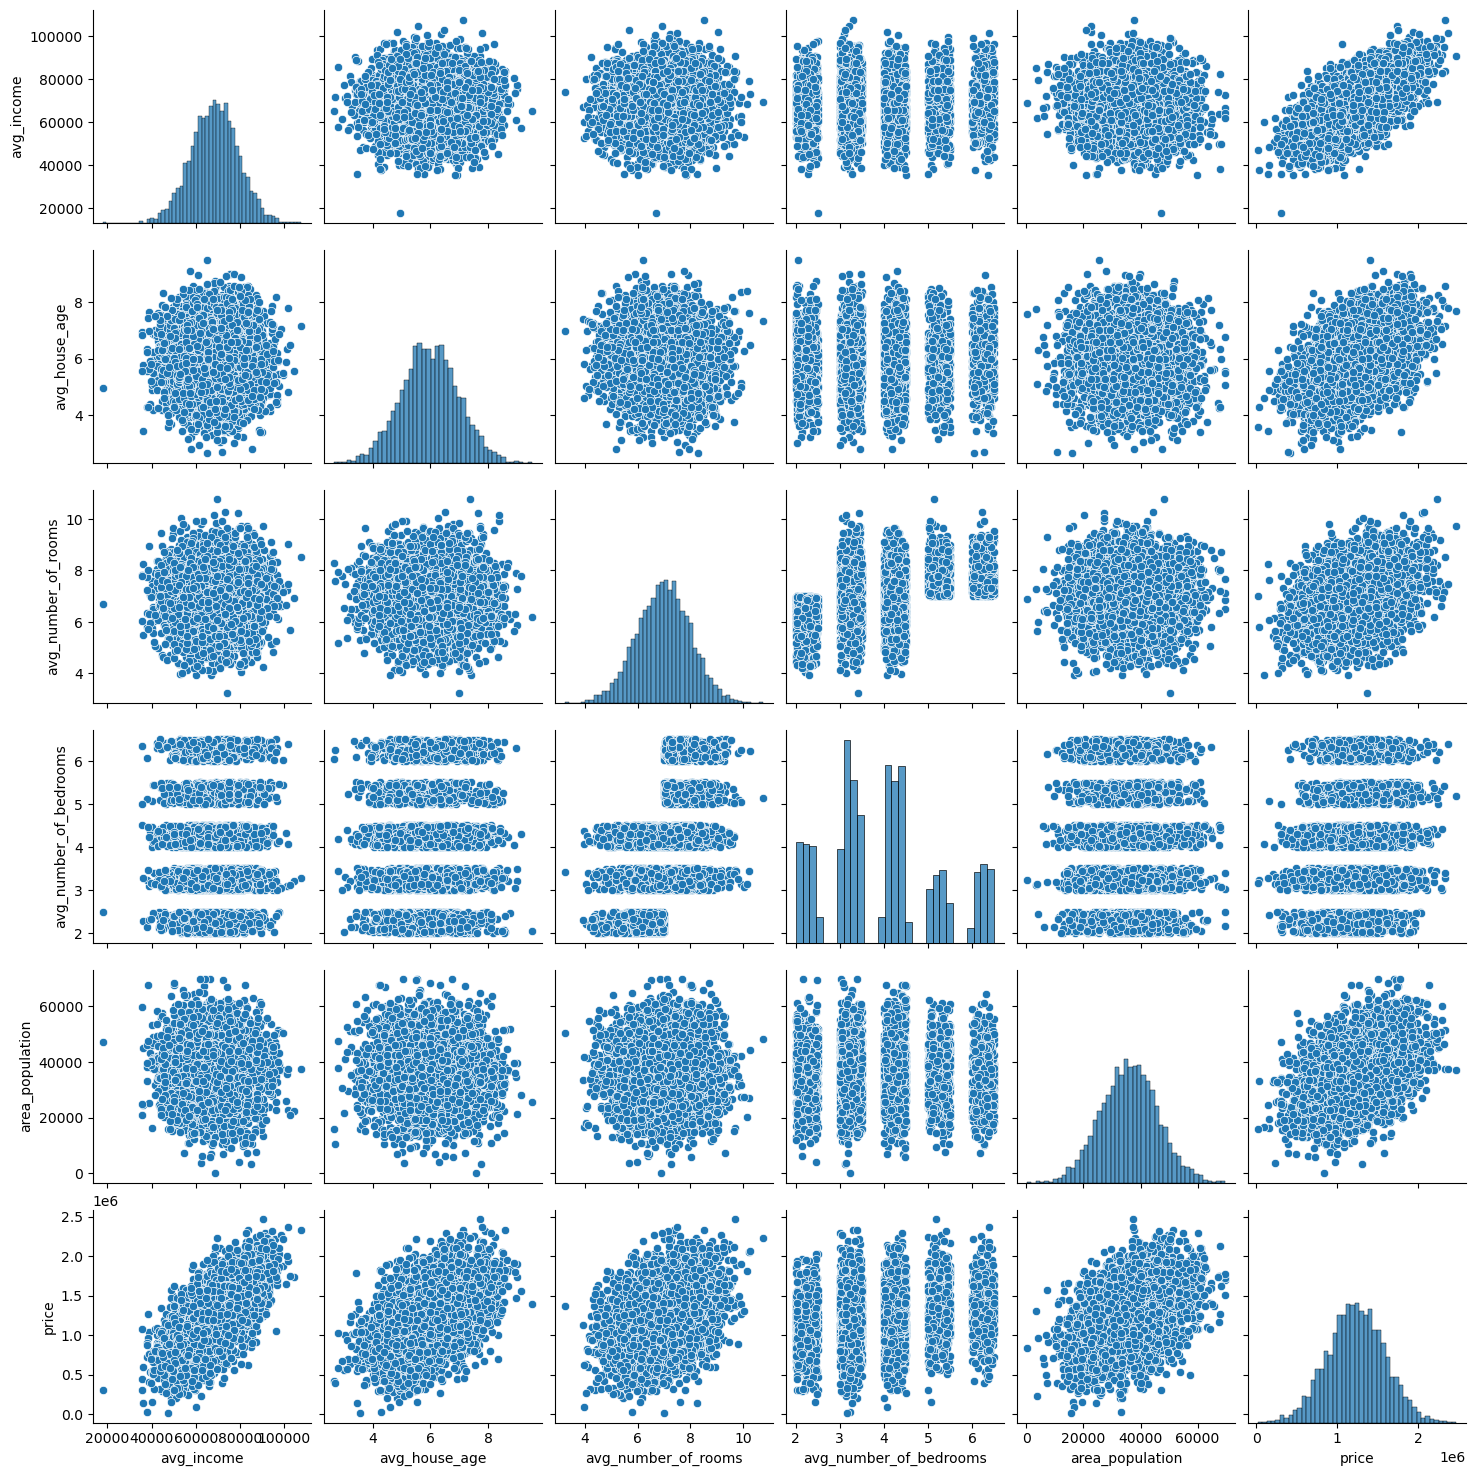

In [24]:
sns.pairplot(housing)

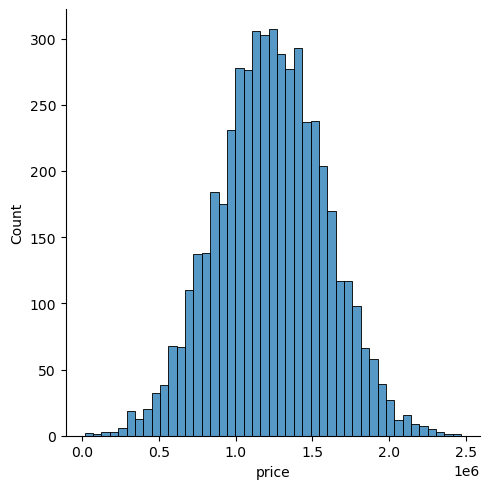

In [26]:
sns.displot(housing['price']);

### Linear Regression Model

* Split up our data into an X array that contains the features to train on, and a y array with the target variable, in this case the Price column.

* Remove the address column since it only has text info.

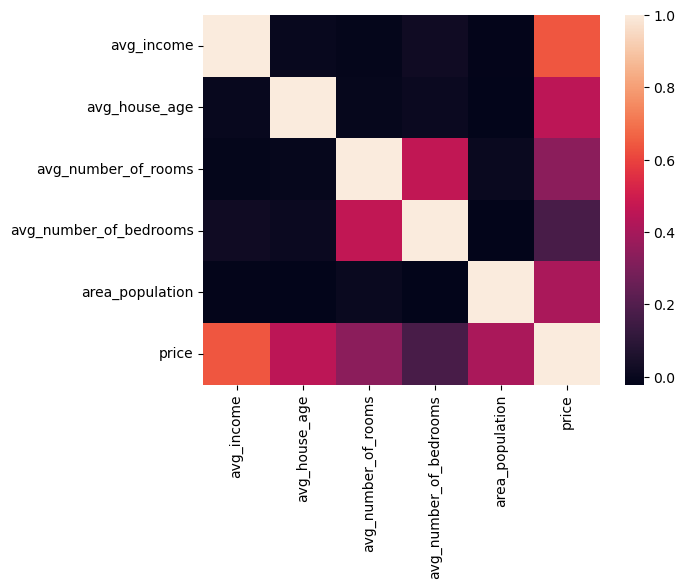

In [28]:
sns.heatmap(housing.corr(numeric_only=True));

In [29]:
housing.columns

Index(['avg_income', 'avg_house_age', 'avg_number_of_rooms',
       'avg_number_of_bedrooms', 'area_population', 'price', 'address'],
      dtype='object')

In [30]:
y = housing['price'].copy()
X = housing.drop(['price', 'address'], axis=1)

### Train Test Split

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, shuffle=True, random_state=42)

In [33]:
X_train

,avg_income,avg_house_age,avg_number_of_rooms,avg_number_of_bedrooms,area_population
1522,67716.748222,6.431119,7.753989,5.28,40562.188948
835,78095.352630,6.837193,7.119862,3.00,32346.434992
358,55577.071754,6.533916,7.162536,3.47,19560.012414
138,63876.059910,7.080219,7.187433,3.37,38052.876443
299,52188.118727,5.636892,5.807401,4.03,42495.754677
...,...,...,...,...,...
4426,76223.561256,6.371627,5.342217,2.42,30165.337445
466,56685.014442,6.958045,7.502115,3.38,43322.166854
3092,66195.337714,6.507971,6.611861,3.14,37288.923574
3772,58694.515017,7.394768,9.269453,4.32,49960.977236


### Create and Train Model

In [34]:
from sklearn.linear_model import LinearRegression

In [35]:
lm = LinearRegression()

In [36]:
lm.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Model Evaluation

In [37]:
print(lm.intercept_)

-2638142.110430866


In [39]:
coef_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
coef_df

,Coefficient
avg_income,21.589887
avg_house_age,166102.501246
avg_number_of_rooms,119895.936402
avg_number_of_bedrooms,1901.071012
area_population,15.231503


### Interpreting the results

- Ceterus Paribus === "Holding all other features fixed" (CP).
- CP, a 1 unit increase in **avg_income** is associated with an **increase of \$21.59**.
- CP, a 1 unit increase in **avg_house_age** is associated with an **increase of 166102.50**.
- CP, a 1 unit increase in **avg_number_of_rooms** is associated with an **increase of 119896**.
- CP, a 1 unit increase in **avg_number_of_bedrooms** is associated with an **increase of 1901**.
- CP, a 1 unit increase in **area_population** is associated with an **increase of 15.23**.

### Model Predictions

In [40]:
predictions = lm.predict(X_test)

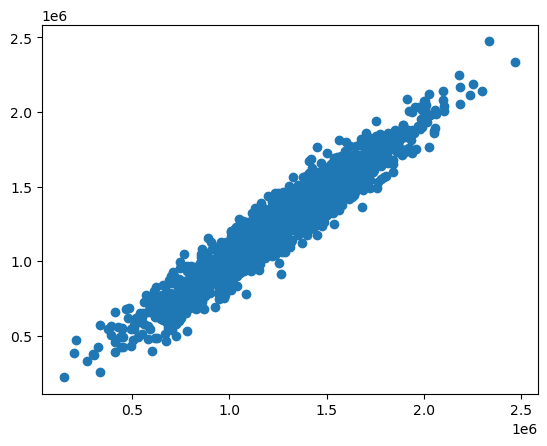

In [42]:
plt.scatter(y_test, predictions)
plt.show()

### Residual Plot

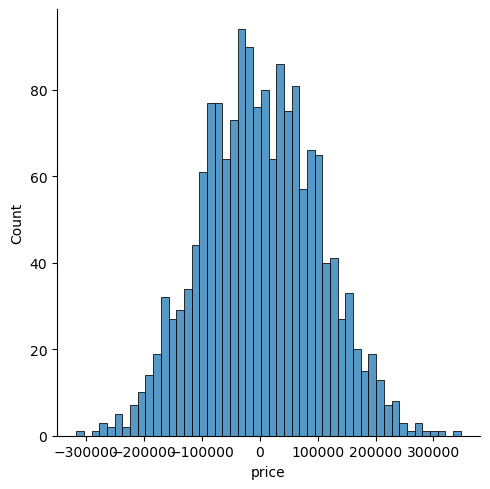

In [43]:
sns.displot((y_test - predictions), bins=50)
plt.show()

In [44]:
from sklearn import metrics

In [45]:
print("MAE", metrics.mean_absolute_error(y_test, predictions))
print("MSE", metrics.mean_squared_error(y_test, predictions))
print("RMSE", np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE 80893.81190770479
MSE 10013679978.583364
RMSE 100068.376516177
